# Arccos On-Course Analysis

End-to-end analysis of your shot-tracked rounds from Arccos. Anchored to the data
pulled by `chrisdecali/golf-reports` into `~/golf-data/` and loaded via
`arccos.loader.load_arccos`.

Four sections:

1. **Strokes gained by category over time** — where are you actually losing strokes,
   and is the trend improving?
2. **Club carry & dispersion on-course** — what each club really carries when it
   counts, compared to your GC3 range data + the forecasted targets.
3. **Course-management decisions** — driver vs 3W off the tee, approach SG by
   distance bucket. Where execution ends and decision-making begins.
4. **Practice priorities** — strokes lost per round per category, translated
   into where one hour of practice buys you the most.

> **Provenance note**: Arccos category SG (`sg_*_arccos`) is the authoritative
> "vs scratch" number. Per-shot SG (`sg_shot_approx`) is reconstructed from a
> published Broadie baseline — directionally accurate, but don't read individual
> shots like the gospel.

In [1]:
# --- Setup ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arccos import load_arccos

# Repo-style: make matplotlib readable in dark/light themes alike.
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3})

data = load_arccos()
print(data.summary())

Arccos store: C:\Users\zfreitas\golf-data
  rounds:       50  date range 2023-08-10 to 2026-06-26
  holes:       599
  shots:      3012  GPS=yes
  clubs.csv:    39  (paired + unpaired, mixed)
  paired bag:   14  (authoritative — from clubs_v6.json)


### Current paired bag

Authoritative Smart Distance per club (from Arccos's v6 endpoint), filtered
to currently-paired sensors only. The puller's `clubs.csv` mixes in retired
clubs; this view doesn't.

In [2]:
bag_view = data.paired_bag[["label", "make", "model",
                            "smart_distance_yd", "longest_yd"]].copy()
bag_view.columns = ["Club", "Make", "Model", "Smart Distance (yd)", "Longest (yd)"]
bag_view

,Club,Make,Model,Smart Distance (yd),Longest (yd)
0,Driver,TaylorMade,Qi10,217.2,252.8
1,3 Wood,TaylorMade,Qi10,197.7,224.7
2,3 Hybrid,TaylorMade,Qi10,181.6,227.2
3,Hybrid,TaylorMade,Qi10,166.3,188.0
4,5 Iron,TaylorMade,P∙770,152.9,160.0
5,6 Iron,TaylorMade,P∙770,140.9,169.7
6,7 Iron,TaylorMade,P∙770,129.4,143.7
7,8 Iron,TaylorMade,P∙770,124.5,136.1
8,9 Iron,TaylorMade,P∙770,107.8,133.0
9,Pitching Wedge,TaylorMade,P∙770,107.3,127.1


## 1. Strokes gained by category over time

Each row in `rounds_summary.csv` carries Arccos's measured SG vs scratch for
off-tee, approach, short game, putting, and total. Below: per-category mean
across all rounds, plus a rolling-5-round trend so you can see if the most
recent stretch is better or worse than the long-term average.

In [3]:
SG_COLS = ["sg_off_tee_arccos", "sg_approach_arccos",
           "sg_short_arccos", "sg_putting_arccos", "sg_total_arccos"]
SG_LABELS = {
    "sg_off_tee_arccos": "Off-tee",
    "sg_approach_arccos": "Approach",
    "sg_short_arccos": "Short game",
    "sg_putting_arccos": "Putting",
    "sg_total_arccos": "Total",
}

r = data.rounds.sort_values("date").reset_index(drop=True)

overall = r[SG_COLS].mean().rename(SG_LABELS).round(2)
recent = r.tail(10)[SG_COLS].mean().rename(SG_LABELS).round(2)
out = pd.concat({"All rounds": overall, "Last 10 rounds": recent}, axis=1)
out["Delta (last 10 vs all)"] = (out["Last 10 rounds"] - out["All rounds"]).round(2)
out

,All rounds,Last 10 rounds,Delta (last 10 vs all)
Off-tee,-3.84,-3.73,0.11
Approach,-5.79,-6.02,-0.23
Short game,-2.45,-1.81,0.64
Putting,-3.10,-1.58,1.52
Total,-15.11,-13.15,1.96


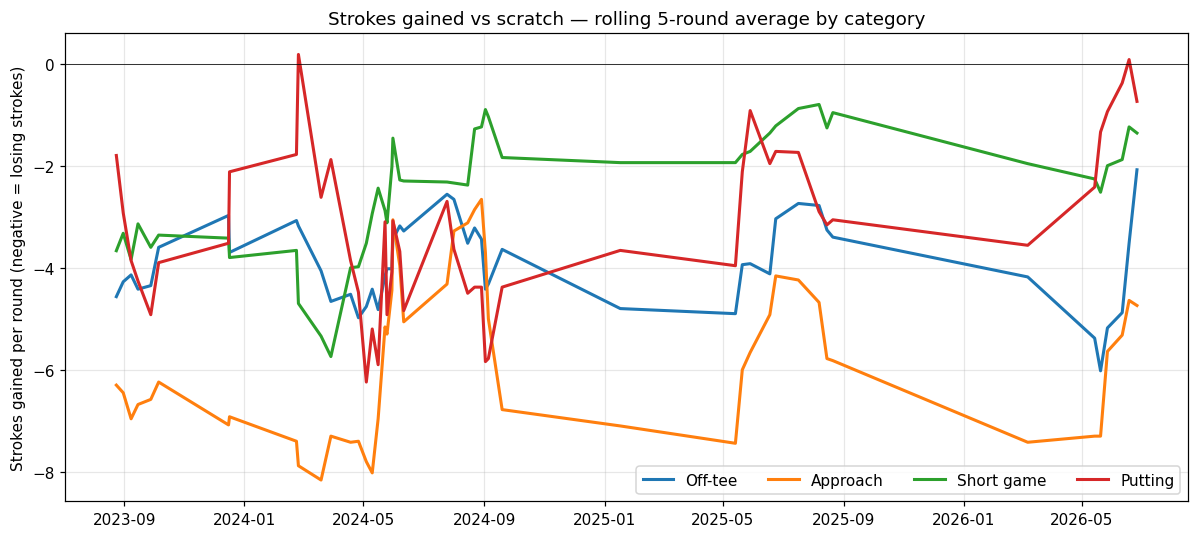

In [4]:
# Rolling-5-round trend in each category. Negative = losing strokes vs scratch.
fig, ax = plt.subplots(figsize=(11, 5))
for col in SG_COLS[:-1]:  # skip total — it's the sum
    series = r[col].rolling(5, min_periods=3).mean()
    ax.plot(r["date"], series, label=SG_LABELS[col], linewidth=2)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Strokes gained vs scratch — rolling 5-round average by category")
ax.set_ylabel("Strokes gained per round (negative = losing strokes)")
ax.legend(loc="lower right", ncol=4)
plt.tight_layout()
plt.show()

## 2. Club carry & dispersion on-course

What each club actually carries when it matters. Sources Arccos's `shot_distance_yd`
per shot, drops putts, and reports the median + 80% band per club. Then sits the
on-course median next to your launch-monitor median and the forecasted target.

In [5]:
def per_club_distance(shots: pd.DataFrame, min_count: int = 6) -> pd.DataFrame:
    # Per-club shot-distance stats from Arccos shots.csv (TOTAL distance,
    # not carry — includes roll/bounce). Filters out putts and zero-distance
    # rows. min_count guards against clubs used so rarely they do not
    # generalize (5+ per upstream README).
    s = shots[~shots["is_putt"].astype(bool) & (shots["shot_distance_yd"] > 0)]
    g = s.groupby("club")["shot_distance_yd"]
    out = pd.DataFrame({
        "shots": g.size(),
        "median": g.median().round(0),
        "p20": g.quantile(0.2).round(0),
        "p80": g.quantile(0.8).round(0),
    })
    out["80% band"] = (out["p80"] - out["p20"]).round(0)
    out = out[out["shots"] >= min_count].sort_values("median", ascending=False)
    return out

clubs_on_course = per_club_distance(data.shots_in_bag())
clubs_on_course

,shots,median,p20,p80,80% band
club,,,,,
Driver,427,195.0,162.0,215.0,53.0
3 Wood,71,164.0,96.0,196.0,100.0
Club 35,119,150.0,95.0,178.0,83.0
Hybrid,129,137.0,97.0,158.0,61.0
5 Iron,34,136.0,93.0,154.0,61.0
6 Iron,77,129.0,96.0,140.0,44.0
7 Iron,73,113.0,36.0,128.0,92.0
8 Iron,97,104.0,30.0,124.0,94.0
9 Iron,45,101.0,84.0,108.0,24.0


In [6]:
# Side-by-side: on-course p80 vs Arccos Smart Distance (authoritative).
# Smart Distance is total (carry + roll); shot-distance median is also total,
# so these are comparable units.
bag = data.paired_bag.copy()
bag = bag.dropna(subset=["smart_distance_yd"])
# Join via shots_csv_label (the puller's label that appears in shots.csv)
# rather than the user-friendly display label.
bag = bag.set_index("shots_csv_label")
comp = clubs_on_course.join(
    bag[["label", "smart_distance_yd", "longest_yd"]],
    how="left"
)
comp = comp.rename(columns={
    "label": "Display name",
    "smart_distance_yd": "Smart Distance (yd)",
    "longest_yd": "Longest (yd)",
    "median": "Shots median (yd)",
    "p80": "Shots p80 (yd)",
})
comp = comp[["Display name", "shots", "Smart Distance (yd)", "Shots p80 (yd)",
             "Shots median (yd)", "Longest (yd)", "80% band"]]
comp

,Display name,shots,Smart Distance (yd),Shots p80 (yd),Shots median (yd),Longest (yd),80% band
club,,,,,,,
Driver,Driver,427,217.2,215.0,195.0,252.8,53.0
3 Wood,3 Wood,71,197.7,196.0,164.0,224.7,100.0
Club 35,3 Hybrid,119,181.6,178.0,150.0,227.2,83.0
Hybrid,Hybrid,129,166.3,158.0,137.0,188.0,61.0
5 Iron,5 Iron,34,152.9,154.0,136.0,160.0,61.0
6 Iron,6 Iron,77,140.9,140.0,129.0,169.7,44.0
7 Iron,7 Iron,73,129.4,128.0,113.0,143.7,92.0
8 Iron,8 Iron,97,124.5,124.0,104.0,136.1,94.0
9 Iron,9 Iron,45,107.8,108.0,101.0,133.0,24.0


**How to read this**: `Smart Distance` is what the Arccos app shows — bias-
corrected toward well-struck shots, what to plan around. `Shots p80` is the
recent 80th-percentile from raw shots, useful as a sanity check. `Shots
median` will be lower because mis-hits drag it down. A wide `80% band` means
dispersion is hurting you on that club; a narrow band means you trust it.

## 3. Course-management decisions

Two questions:

- **Driver vs 3-wood off the tee** — which actually saves you strokes? Compares
  per-shot SG when you grab the driver vs your most-used backup tee club.
- **Approach SG by distance bucket** — where on the course do approach shots
  bleed strokes most? Surfaces the "I never hit it close from 150" pattern.

In [7]:
# 3a. Tee-club selection (filtered to currently-paired clubs only)
tee_shots = data.shots_in_bag()[data.shots_in_bag()["is_tee"].astype(bool)].copy()
tee_club_sg = (tee_shots.groupby("club")
               .agg(shots=("sg_shot_approx", "size"),
                    avg_sg=("sg_shot_approx", "mean"),
                    median_dist=("shot_distance_yd", "median"))
               .sort_values("shots", ascending=False))
tee_club_sg = tee_club_sg[tee_club_sg["shots"] >= 5]
tee_club_sg["avg_sg"] = tee_club_sg["avg_sg"].round(3)
tee_club_sg["median_dist"] = tee_club_sg["median_dist"].round(0)
tee_club_sg

,shots,avg_sg,median_dist
club,,,
Driver,426,-0.300,195.0
Hybrid,37,-0.447,151.0
6 Iron,31,-0.446,131.0
7 Iron,17,-0.540,118.0
5 Iron,14,-0.689,144.0
8 Iron,14,-0.255,118.0
Club 35,12,-0.667,134.0
Wedge,11,-0.347,75.0
Pitching Wedge,9,-0.423,109.0


In [8]:
# 3b. Approach SG by distance bucket. Pin distance at shot start is what matters.
sib = data.shots_in_bag()
approach_shots = sib[(sib["category_approx"] == "approach") &
                     (sib["start_dist_to_pin_yd"].notna())].copy()
buckets = [0, 50, 75, 100, 125, 150, 175, 200, 250, 999]
labels = ["<50", "50-75", "75-100", "100-125", "125-150",
          "150-175", "175-200", "200-250", "250+"]
approach_shots["bucket"] = pd.cut(approach_shots["start_dist_to_pin_yd"],
                                  bins=buckets, labels=labels, right=False)
approach_by_bucket = (approach_shots.groupby("bucket", observed=True)
                      .agg(shots=("sg_shot_approx", "size"),
                           avg_sg=("sg_shot_approx", "mean"),
                           median_proximity=("end_dist_to_pin_yd", "median"))
                      .round(2))
approach_by_bucket

,shots,avg_sg,median_proximity
bucket,,,
<50,131,-0.23,9.90
50-75,92,-0.15,10.95
75-100,88,-0.25,16.00
100-125,145,-0.32,17.55
125-150,162,-0.42,24.40
150-175,109,-0.43,28.80
175-200,48,-0.31,45.05
200-250,35,-0.29,76.60
250+,108,-0.24,153.25


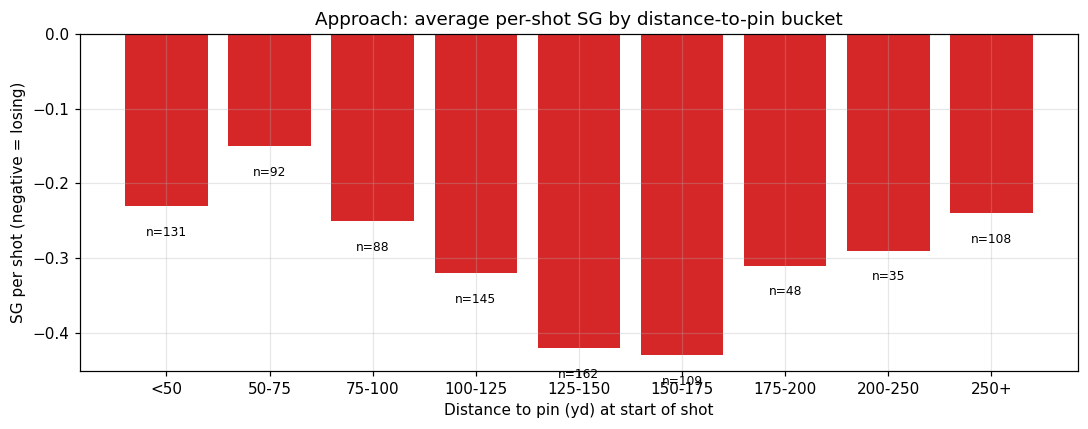

In [9]:
# Visualize approach SG by distance bucket — green = saving strokes, red = losing.
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in approach_by_bucket["avg_sg"]]
ax.bar(approach_by_bucket.index.astype(str), approach_by_bucket["avg_sg"], color=colors)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Approach: average per-shot SG by distance-to-pin bucket")
ax.set_ylabel("SG per shot (negative = losing)")
ax.set_xlabel("Distance to pin (yd) at start of shot")
for i, (n, v) in enumerate(zip(approach_by_bucket["shots"], approach_by_bucket["avg_sg"])):
    ax.text(i, v + (0.02 if v >= 0 else -0.04), f"n={n}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Practice priorities

For each category, compute **strokes lost per round vs scratch** and **rank**.
The biggest negative is where one hour of practice buys you the most. A rough
practice-time allocation is suggested proportional to strokes-lost — feel free
to weight by what you actually enjoy practicing.

In [10]:
priorities = (data.rounds[SG_COLS[:-1]].mean()
              .rename(SG_LABELS).rename("Avg SG per round")
              .to_frame())
priorities["Strokes LOST per round"] = (-priorities["Avg SG per round"]).clip(lower=0)
total_lost = priorities["Strokes LOST per round"].sum()
if total_lost > 0:
    priorities["Practice-time share"] = (
        (priorities["Strokes LOST per round"] / total_lost * 100).round(0)
        .astype(int).astype(str) + " %"
    )
else:
    priorities["Practice-time share"] = "—"
priorities = priorities.sort_values("Strokes LOST per round", ascending=False)
priorities

,Avg SG per round,Strokes LOST per round,Practice-time share
Approach,-5.790000,5.790000,38 %
Off-tee,-3.836735,3.836735,25 %
Putting,-3.102000,3.102000,20 %
Short game,-2.450000,2.450000,16 %


### Practice translation

- **Strokes lost per round** is what each category costs you vs scratch — this is
  what to *fix*, not just what to *practice the most*.
- **Practice-time share** is purely proportional to strokes lost. Treat it as a
  starting point: a category you enjoy practicing is one you'll actually
  practice, which compounds into improvement faster than the optimal split
  you abandon after a week.
- **Cross-reference with Section 2** — if approach is your biggest leak AND your
  on-course 7i carry is 7 yd shorter than your range carry, the gap isn't
  swing speed, it's strike consistency under pressure. That's a range-session
  fix (which the GC3 notebook already flagged: spin too low, smash too low).